# **Chocolate Sales Data Analysis(2023-2024)**

## Project Overview
This project analyzes chocolate sales data to uncover patterns in sales performance across products, countries, and sales representatives.
The analysis demonstrates practical data analytics skills including data cleaning, exploratory data analysis, aggregation, ranking, and data visualization using Python and Pandas.

## Business Questions
- Which chocolate products generate the highest sales?
- Which countries have the strongest sales performance?
- Which sales representatives generate the most sales?
- How do sales vary across products and markets?
- What patterns or trends can be identified from the available sales data?

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
df = pd.read_excel("sample-chocolate-sales-data-1.xlsx")

In [18]:
df.head()

,Sales Person,Product,Country,Date,Amount,Boxes,Order Status
0,Jehu Rudeforth,White Choc,USA,2023-01-02,5879.25,236,Delivered
1,Roddy Speechley,Choco Coated Almonds,UK,2023-01-02,2110.50,141,Delivered
2,Oby Sorrel,Raspberry Choco,UK,2023-01-02,9058.50,906,Cancelled
3,Camilla Castle,50% Dark Bites,USA,2023-01-02,1228.50,73,Delivered
4,Madelene Upcott,Baker's Choco Chips,Canada,2023-01-02,5451.75,321,Delivered


In [19]:
df.columns

Index(['Sales Person', 'Product', 'Country', 'Date', 'Amount', 'Boxes',
       'Order Status'],
      dtype='object')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Sales Person  4998 non-null   object        
 1   Product       4998 non-null   object        
 2   Country       4998 non-null   object        
 3   Date          4998 non-null   datetime64[ns]
 4   Amount        4998 non-null   float64       
 5   Boxes         4998 non-null   int64         
 6   Order Status  4998 non-null   object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 273.5+ KB


In [21]:
df.dtypes

Sales Person            object
Product                 object
Country                 object
Date            datetime64[ns]
Amount                 float64
Boxes                    int64
Order Status            object
dtype: object

In [22]:
df.isnull().sum()

Sales Person    0
Product         0
Country         0
Date            0
Amount          0
Boxes           0
Order Status    0
dtype: int64

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df.tail()

,Sales Person,Product,Country,Date,Amount,Boxes,Order Status
4993,Brien Boise,Choco Coated Almonds,UK,2024-09-27,7641.00,765,Placed
4994,Gunar Cockshoot,85% Dark Bars,India,2024-09-27,10203.75,486,Placed
4995,Gunar Cockshoot,Baker's Choco Chips,UK,2024-09-30,9807.75,545,Placed
4996,Gigi Bohling,Choco Coated Almonds,USA,2024-09-30,335.25,28,Placed
4997,Gunar Cockshoot,Choco Coated Almonds,New Zealand,2024-09-30,3609.00,301,Placed


In [25]:
df.shape

(4998, 7)

## Key Performance Indicators (KPIs)

The following KPIs provide a quick overview of the overall sales performance:

- Total Revenue
- Average Order Value
- Total Orders
- Number of Countries
- Number of Products
- Cancellation Rate

In [26]:
df.describe()

,Date,Amount,Boxes
count,4998,4998.000000,4998.000000
mean,2023-11-15 04:59:21.104441856,5600.411615,397.949580
min,2023-01-02 00:00:00,2.250000,1.000000
25%,2023-06-15 00:00:00,2756.812500,168.000000
50%,2023-11-13 00:00:00,5167.125000,315.000000
75%,2024-04-21 06:00:00,7637.625000,513.000000
max,2024-09-30 00:00:00,24108.750000,3385.000000
std,NaN,3780.856987,363.396528


In [27]:
# Key Performance Indicators

total_revenue = df["Amount"].sum()
average_order_value = df["Amount"].mean()
total_orders = df.shape[0]
number_of_countries = df["Country"].nunique()
number_of_products = df["Product"].nunique()

cancellation_rate = (
    df["Order Status"].eq("Cancelled").mean() * 100
)

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Average Order Value: ${average_order_value:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Number of Countries: {number_of_countries}")
print(f"Number of Products: {number_of_products}")
print(f"Cancellation Rate: {cancellation_rate:.2f}%")

Total Revenue: $27,990,857.25
Average Order Value: $5,600.41
Total Orders: 4,998
Number of Countries: 6
Number of Products: 22
Cancellation Rate: 4.54%


In [28]:
df.loc[:,['Boxes', 'Order Status']].idxmax()

Boxes           2435
Order Status    4329
dtype: int64

### Which sales representatives generate the most sales?

In [30]:
Revenue_by_salesperson = df.groupby("Sales Person")["Amount"].sum().sort_values(ascending=False)

In [31]:
Revenue_by_salesperson.head()

Sales Person
Brien Boise        2170955.25
Madelene Upcott    2025711.00
Dotty Strutley     1665866.25
Gunar Cockshoot    1639838.25
Kelci Walkden      1575065.25
Name: Amount, dtype: float64

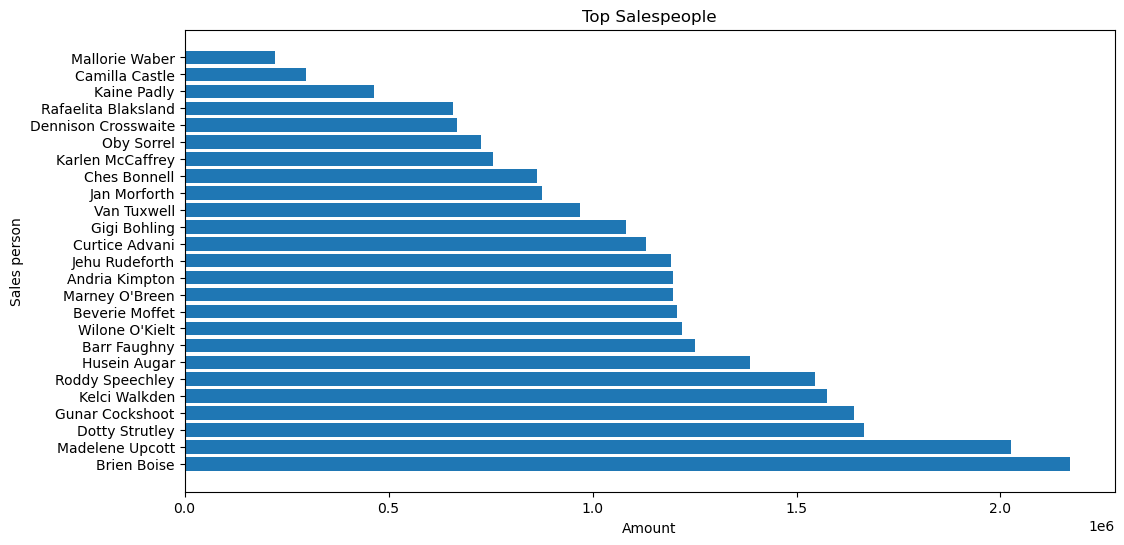

In [32]:

plt.figure(figsize=(12,6))
plt.barh(Revenue_by_salesperson.index, Revenue_by_salesperson.values)
plt.title("Top Salespeople")
plt.xlabel("Amount")
plt.ylabel("Sales person")
plt.show()

#### Insight:
A few salespeople are responsible for a large portion of total sales. Recognizing top performers and sharing their best practices can help improve the performance of the entire sales team.

### Which countries have the strongest sales performance?

In [33]:
sales_by_country = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)

In [34]:
sales_by_country.head()

Country
UK             7657974.00
USA            6277893.75
India          4583074.50
Canada         3264612.75
New Zealand    3115964.25
Name: Amount, dtype: float64

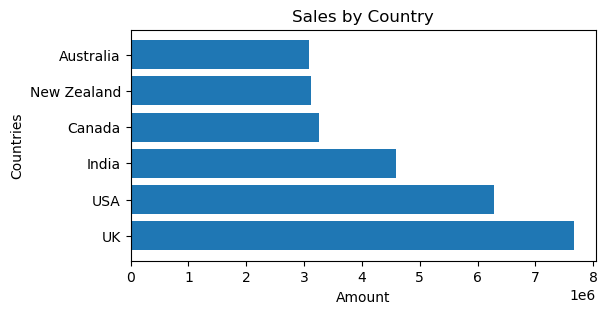

In [35]:

plt.figure(figsize=(6, 3))
plt.barh(sales_by_country.index, sales_by_country.values)
plt.title("Sales by Country")
plt.xlabel("Amount")
plt.ylabel("Countries")
plt.show()


#### Insight:
Sales performance varies strongly by country. The top countries generate a large share of total revenue, suggesting that targeted marketing and stronger distribution in these markets would be beneficial

### Which chocolate products generate the highest sales?

In [39]:
products_revenue = df.groupby('Product')['Amount'].sum().sort_values(ascending=False)

In [40]:
products_revenue.head()

Product
Orange Choco           1861962.75
Drinking Coco          1850361.75
99% Dark & Pure        1845753.75
Organic Choco Syrup    1834641.00
Peanut Butter Cubes    1818416.25
Name: Amount, dtype: float64

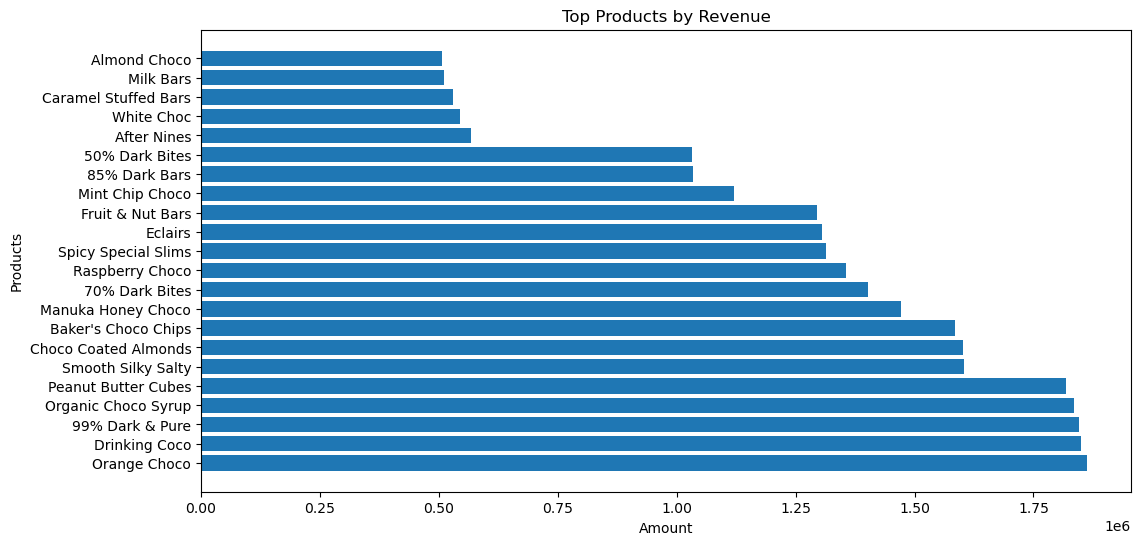

In [41]:
plt.figure(figsize=(12,6))
plt.barh(products_revenue.index, products_revenue.values)
plt.title("Top Products by Revenue")
plt.xlabel("Amount")
plt.ylabel("Products")
plt.show()

#### Insight:
A small number of products contribute to the majority of total revenue. Focusing marketing, promotions, and inventory on these top products can significantly boost overall sales performance.

### What is the Order Status breakdown?

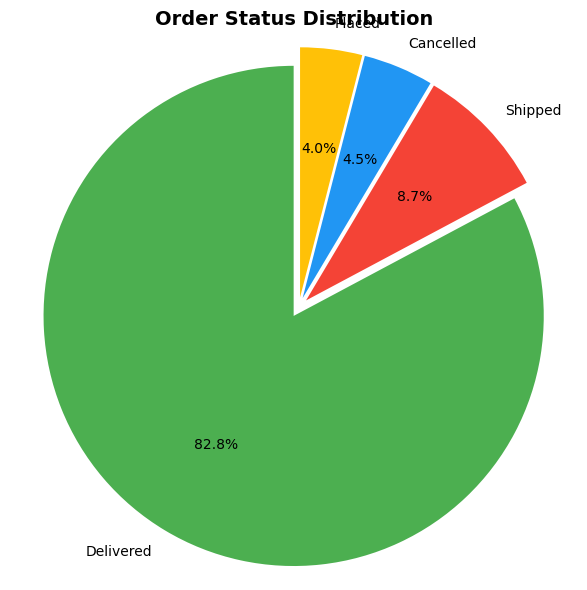

In [43]:
status = df['Order Status'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(status.values, 
        labels=status.index, 
        autopct='%1.1f%%', 
        startangle=90,
        colors=['#4CAF50', '#F44336', '#2196F3', '#FFC107'],
        explode=[0.04] * len(status))

plt.title("Order Status Distribution", fontsize=14, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

#### Insight  
The majority of orders are successfully Delivered. However, Cancelled orders still represent a noticeable portion. Reducing cancellations should be a priority to protect revenue.

### How are monthly sales trending?

In [44]:
df["Date"] = pd.to_datetime(df["Date"])
monthly_sales = df.groupby(
    df["Date"].dt.to_period("M")
)["Amount"].sum()

monthly_sales

Date
2023-01    1219898.25
2023-02     973687.50
2023-03    1043628.75
2023-04    1383275.25
2023-05    1379398.50
2023-06    1620643.50
2023-07    1469220.75
2023-08    1639136.25
2023-09    1557321.75
2023-10    1087553.25
2023-11    1237900.50
2023-12    1479883.50
2024-01    1481908.50
2024-02    1104723.00
2024-03    1623316.50
2024-04    1226515.50
2024-05    1374473.25
2024-06    1282995.00
2024-07    1273455.00
2024-08    1290206.25
2024-09    1241716.50
Freq: M, Name: Amount, dtype: float64

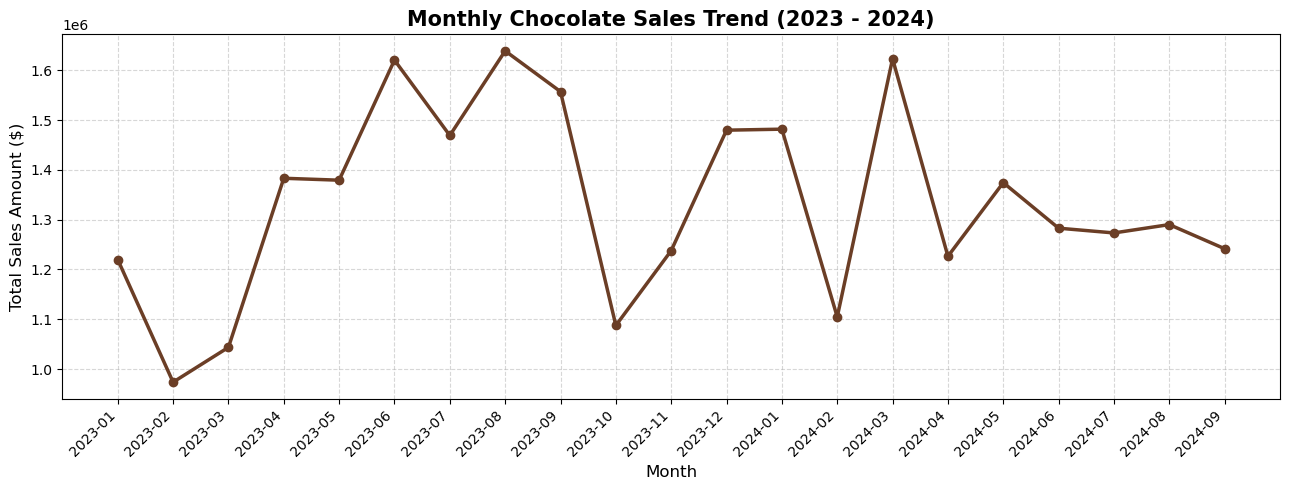

In [45]:
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(13, 5))
plt.plot(monthly_sales.index, monthly_sales.values,
         marker='o', markersize=6, linewidth=2.5, color='#6B3E26')

plt.title("Monthly Chocolate Sales Trend (2023 - 2024)", fontsize=15, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Sales Amount ($)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### Insight 
Monthly sales show noticeable fluctuations throughout 2023 and 2024. Identifying the reasons behind high and low performing months can help in better planning and forecasting.